# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Muhammad Irzam Hafis Fabiansyah | 5054251024 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset: [Breast Cancer Wisconsin (Diagnostic)](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data) via `kagglehub` (`uciml/breast-cancer-wisconsin-data`, 569 sampel, 30 fitur numerik, target `diagnosis` M/B).

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Path to dataset files:", path)

Path to dataset files: /home/irzam/.cache/kagglehub/datasets/uciml/breast-cancer-wisconsin-data/versions/2


In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
import os
csv_path = os.path.join(path, "data.csv")
print("CSV:", csv_path)
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
display(df.head())
print("\nKolom:", df.columns.tolist())
df.info()
print("\nJumlah missing value per kolom (total):", int(df.isna().sum().sum()))
print("\nMissing per kolom (hanya yang > 0):")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nJumlah baris duplikat:", int(df.duplicated().sum()))
display(df.describe().T)

CSV: /home/irzam/.cache/kagglehub/datasets/uciml/breast-cancer-wisconsin-data/versions/2/data.csv
Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Kolom: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    fl

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    0.6274
M    0.3726
Name: proportion, dtype: float64


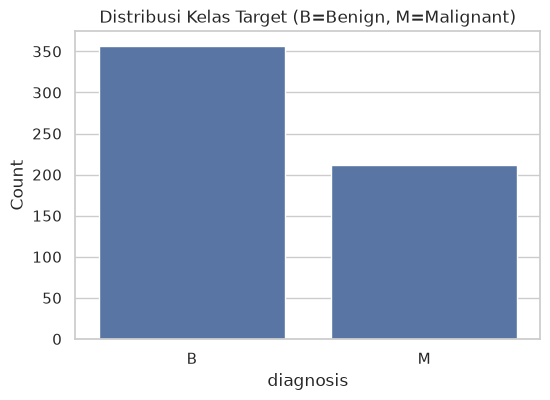

In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
print(df["diagnosis"].value_counts())
print(df["diagnosis"].value_counts(normalize=True).round(4))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="diagnosis", order=["B", "M"])
plt.title("Distribusi Kelas Target (B=Benign, M=Malignant)")
plt.xlabel("diagnosis")
plt.ylabel("Count")
plt.show()

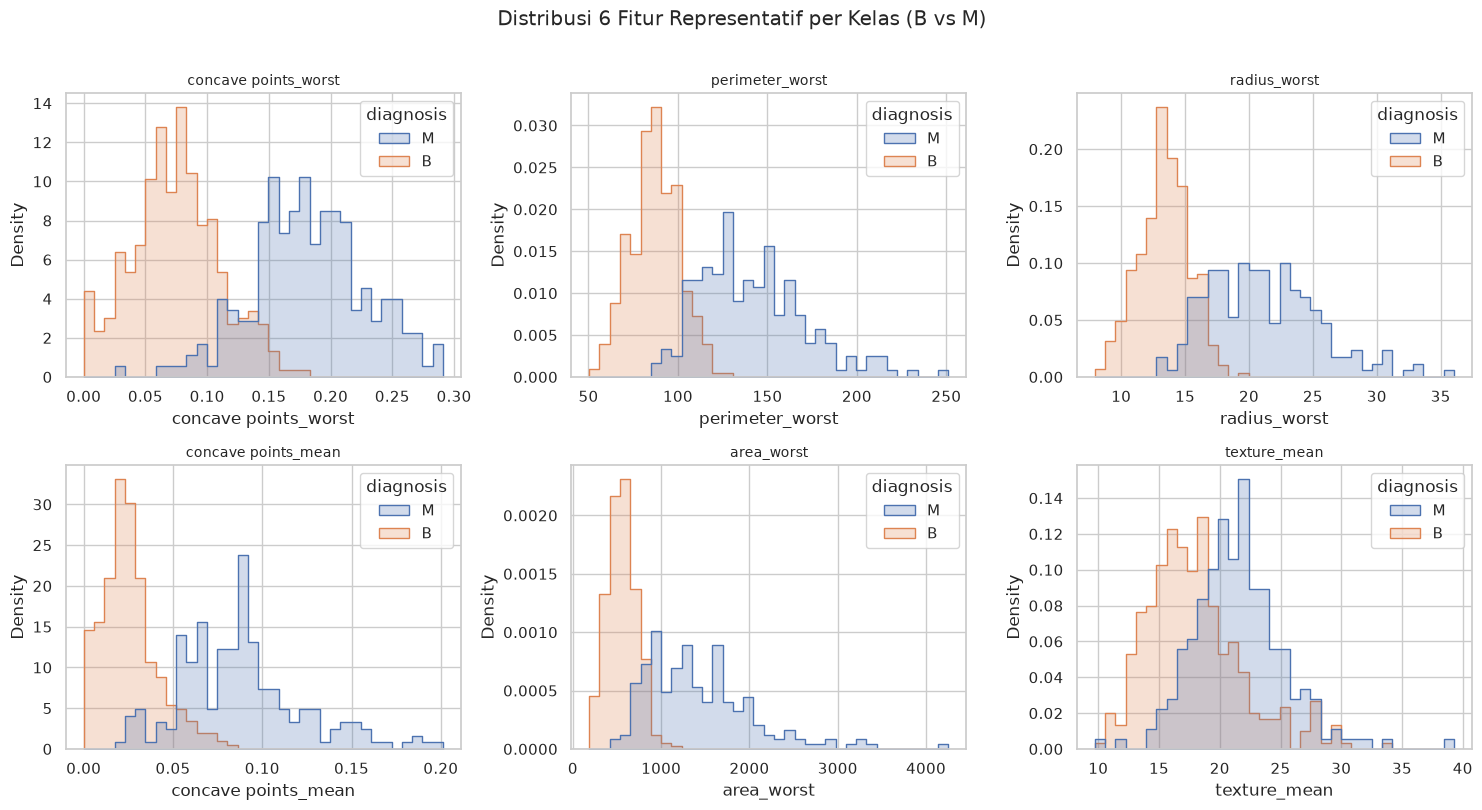

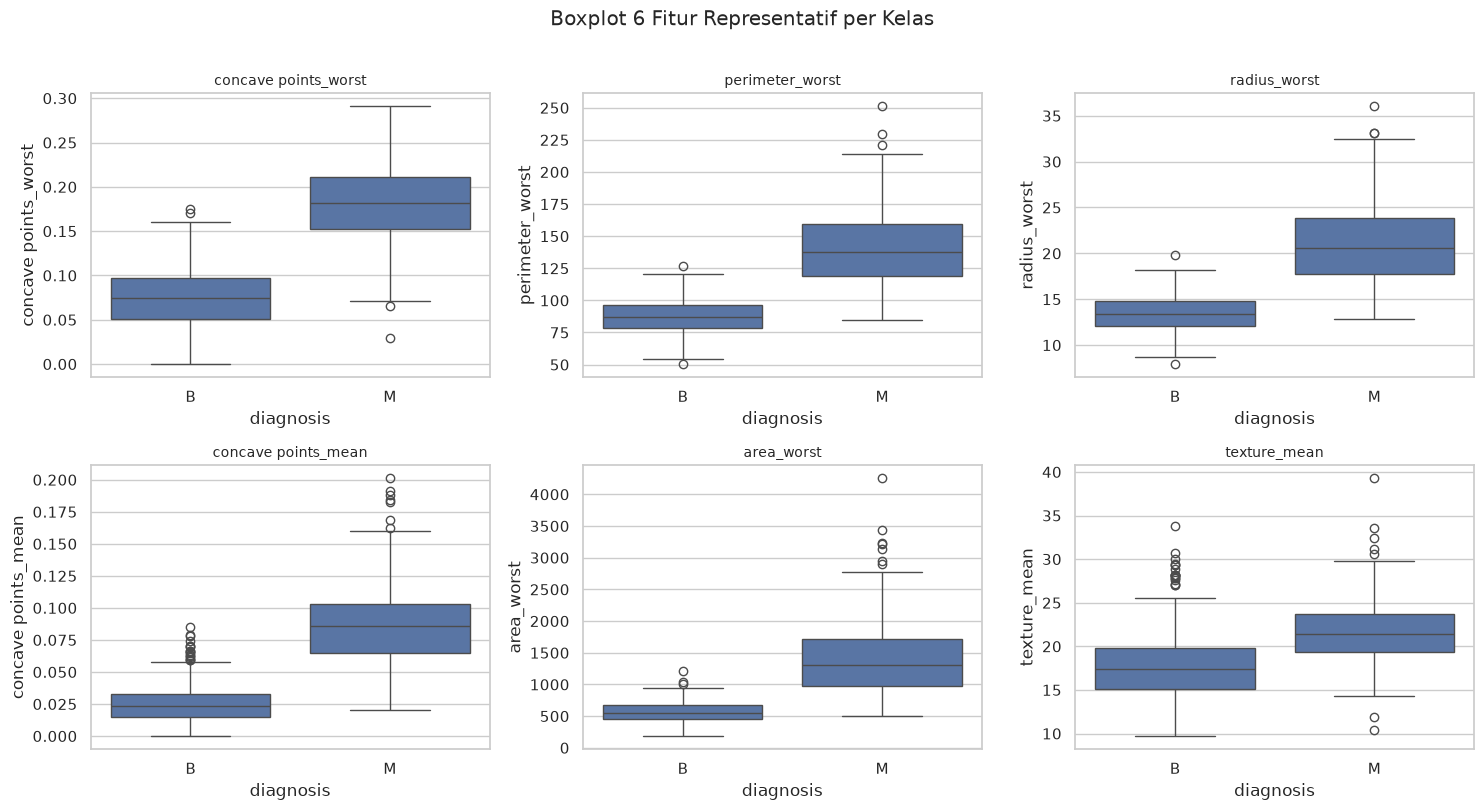

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas (linear) antar kelas, atau justru tumpang tindih.
# 30 fitur terlalu banyak untuk pairplot -> gunakan 6 fitur representatif ( Worst features yang paling berkorelasi dengan target).
rep_features = ["concave points_worst", "perimeter_worst", "radius_worst",
                "concave points_mean", "area_worst", "texture_mean"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), rep_features):
    sns.histplot(data=df, x=feat, hue="diagnosis", bins=35, element="step",
                 stat="density", common_norm=False, ax=ax)
    ax.set_title(feat, fontsize=10)
plt.suptitle("Distribusi 6 Fitur Representatif per Kelas (B vs M)", y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), rep_features):
    sns.boxplot(data=df, x="diagnosis", y=feat, order=["B", "M"], ax=ax)
    ax.set_title(feat, fontsize=10)
plt.suptitle("Boxplot 6 Fitur Representatif per Kelas", y=1.01)
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

concave points_worst    0.7936
perimeter_worst         0.7829
concave points_mean     0.7766
radius_worst            0.7765
perimeter_mean          0.7426
area_worst              0.7338
radius_mean             0.7300
area_mean               0.7090
concavity_mean          0.6964
concavity_worst         0.6596
Name: diagnosis, dtype: float64


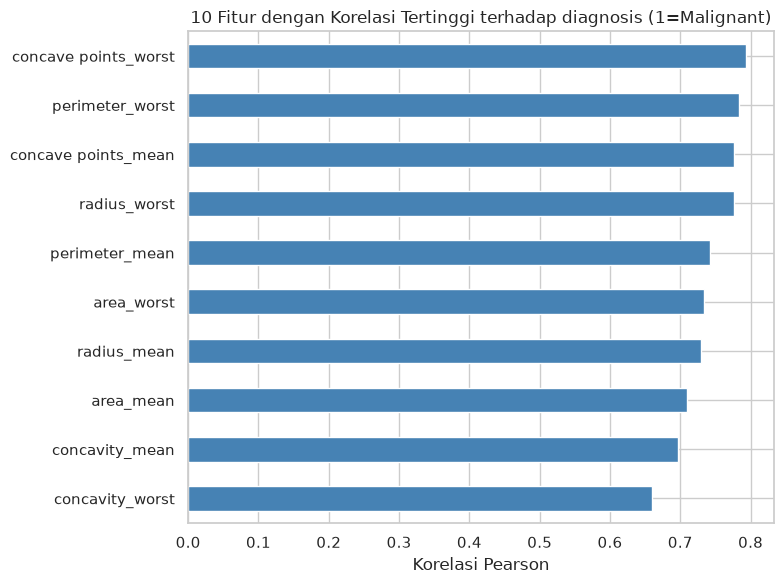

In [5]:
# EDA tambahan 1: korelasi tiap fitur terhadap target -> 10 fitur paling berkorelasi.
# diagnosis masih string 'B'/'M' di tahap ini -> buat salinan numerik sementara (M=1, B=0).
df_num = df.drop(columns=["id", "Unnamed: 32"]).copy()
df_num["diagnosis"] = (df_num["diagnosis"] == "M").astype(int)
corr_target = df_num.corr(numeric_only=True)["diagnosis"].drop("diagnosis").sort_values(key=abs, ascending=False)
print(corr_target.head(10).round(4))

plt.figure(figsize=(8, 6))
corr_target.head(10).sort_values().plot(kind="barh", color="steelblue")
plt.title("10 Fitur dengan Korelasi Tertinggi terhadap diagnosis (1=Malignant)")
plt.xlabel("Korelasi Pearson")
plt.tight_layout()
plt.show()


In [6]:
# EDA tambahan 2: perbandingan rata-rata fitur antar kelas (8 fitur top korelasi).
compare = df_num.groupby("diagnosis")[corr_target.head(8).index.tolist()].mean().T
compare.columns = ["Benign (0)", "Malignant (1)"]
print(compare.round(4))


                      Benign (0)  Malignant (1)
concave points_worst      0.0744         0.1822
perimeter_worst          87.0059       141.3703
concave points_mean       0.0257         0.0880
radius_worst             13.3798        21.1348
perimeter_mean           78.0754       115.3654
area_worst              558.8994      1422.2863
radius_mean              12.1465        17.4628
area_mean               462.7902       978.3764


# 2. Preprocessing

In [7]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
print("Missing value per kolom (5 teratas):")
print(df.isna().sum().sort_values(ascending=False).head())
print("\nTotal missing:", int(df.isna().sum().sum()))
print("Duplikat:", int(df.duplicated().sum()))
# Hasil: kolom 'Unnamed: 32' seluruhnya NaN (kolom kosong bawaan csv) -> di-drop.
# Tidak ada missing pada fitur/target asli dan tidak ada duplikat, jadi tidak perlu imputasi.
# (Jika ada, imputasi median harus di-fit hanya pada train set agar tidak terjadi leakage.)

Missing value per kolom (5 teratas):
Unnamed: 32     569
id                0
diagnosis         0
texture_mean      0
radius_mean       0
dtype: int64

Total missing: 569
Duplikat: 0


In [8]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Drop kolom non-informatif: 'id' (identifier) dan 'Unnamed: 32' (kolom kosong seluruhnya NaN).
print("Nilai unik diagnosis:", df["diagnosis"].unique())
df = df.drop(columns=["id", "Unnamed: 32"])
# Encode target biner: M (malignant) = 1, B (benign) = 0
df["diagnosis"] = (df["diagnosis"] == "M").astype(int)
print("Setelah encoding, nilai unik diagnosis:", df["diagnosis"].unique())
print("Shape setelah drop kolom:", df.shape)
print(df["diagnosis"].value_counts())

Nilai unik diagnosis: <StringArray>
['M', 'B']
Length: 2, dtype: str
Setelah encoding, nilai unik diagnosis: [1 0]
Shape setelah drop kolom: (569, 31)
diagnosis
0    357
1    212
Name: count, dtype: int64


In [9]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]
print("Jumlah fitur:", X.shape[1])
print("Fitur numerik semua:", X.dtypes.value_counts().to_dict())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Proporsi kelas train:", y_train.value_counts(normalize=True).round(4).to_dict())
print("Proporsi kelas test :", y_test.value_counts(normalize=True).round(4).to_dict())

Jumlah fitur: 30
Fitur numerik semua: {dtype('float64'): 30}
Train shape: (455, 30) | Test shape: (114, 30)
Proporsi kelas train: {0: 0.6264, 1: 0.3736}
Proporsi kelas test : {0: 0.6316, 1: 0.3684}


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [10]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit hanya di train -> tanpa leakage
X_test_s = scaler.transform(X_test)         # transform saja di test
print("Mean 5 fitur pertama setelah scaling (train, ~0):",
      np.round(X_train_s[:, :5].mean(axis=0), 4))
print("Std 5 fitur pertama setelah scaling (train, ~1):",
      np.round(X_train_s[:, :5].std(axis=0), 4))

Mean 5 fitur pertama setelah scaling (train, ~0): [-0.  0.  0. -0.  0.]
Std 5 fitur pertama setelah scaling (train, ~1): [1. 1. 1. 1. 1.]


# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [11]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).
svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_linear.fit(X_train_s, y_train)
print("Model linear terlatih.")
print("Jumlah support vectors per kelas [B, M]:", svm_linear.n_support_.tolist())
print("Total support vectors:", int(svm_linear.n_support_.sum()))

Model linear terlatih.
Jumlah support vectors per kelas [B, M]: [19, 19]
Total support vectors: 38


In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_linear = svm_linear.predict(X_test_s)
print("Akurasi train (linear):", round(svm_linear.score(X_train_s, y_train), 4))
print("Akurasi test  (linear):", round(accuracy_score(y_test, y_pred_linear), 4))

Akurasi train (linear): 0.989
Akurasi test  (linear): 0.9649


## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [13]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_rbf.fit(X_train_s, y_train)
print("Model RBF terlatih.")
print("Jumlah support vectors per kelas [B, M]:", svm_rbf.n_support_.tolist())
print("Total support vectors:", int(svm_rbf.n_support_.sum()))

Model RBF terlatih.
Jumlah support vectors per kelas [B, M]: [50, 57]
Total support vectors: 107


In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_rbf = svm_rbf.predict(X_test_s)
print("Akurasi train (RBF):", round(svm_rbf.score(X_train_s, y_train), 4))
print("Akurasi test  (RBF):", round(accuracy_score(y_test, y_pred_rbf), 4))

Akurasi train (RBF): 0.9868
Akurasi test  (RBF): 0.9737


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [15]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
# Gunakan gamma='scale' atau nilai gamma tetap agar perbandingan fokus pada pengaruh C.
C_values = [0.01, 0.1, 1, 10, 100]
models_C = {}
for C in C_values:
    m = SVC(kernel="rbf", C=C, gamma="scale", random_state=42)
    m.fit(X_train_s, y_train)
    models_C[C] = m
    print(f"C={C}: n_support={m.n_support_.tolist()} total={int(m.n_support_.sum())}")

C=0.01: n_support=[171, 170] total=341
C=0.1: n_support=[101, 101] total=202
C=1: n_support=[50, 57] total=107
C=10: n_support=[42, 40] total=82
C=100: n_support=[35, 35] total=70


In [16]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
train_acc_C, test_acc_C = [], []
for C in C_values:
    m = models_C[C]
    train_acc_C.append(m.score(X_train_s, y_train))
    test_acc_C.append(accuracy_score(y_test, m.predict(X_test_s)))
summary_C = pd.DataFrame({"C": C_values, "train_acc": np.round(train_acc_C, 4),
                          "test_acc": np.round(test_acc_C, 4),
                          "n_sv": [int(models_C[c].n_support_.sum()) for c in C_values]})
print(summary_C.to_string(index=False))

     C  train_acc  test_acc  n_sv
  0.01     0.6264    0.6316   341
  0.10     0.9538    0.9474   202
  1.00     0.9868    0.9737   107
 10.00     0.9890    0.9737    82
100.00     1.0000    0.9649    70


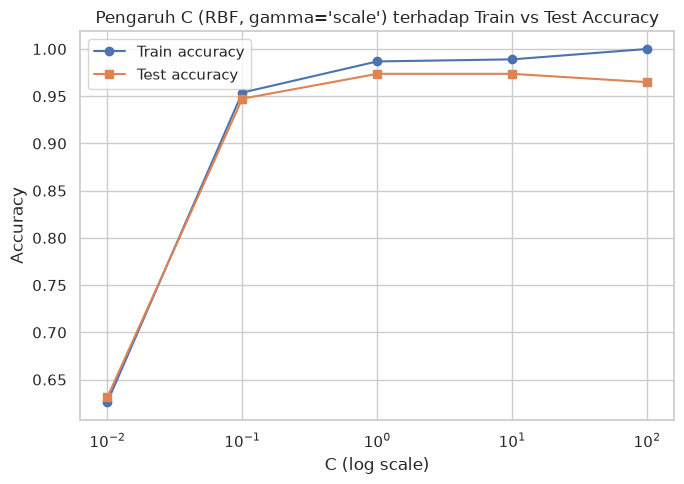

In [17]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(7, 5))
plt.plot(C_values, train_acc_C, marker="o", label="Train accuracy")
plt.plot(C_values, test_acc_C, marker="s", label="Test accuracy")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("Pengaruh C (RBF, gamma='scale') terhadap Train vs Test Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## 3.4 Eksperimen Tambahan: Pengaruh Gamma (RBF, C=1)

Parameter `gamma` mengatur seberapa lokal pengaruh tiap titik data pada kernel RBF: gamma kecil = jangkauan luas (halus), gamma besar = jangkauan sempit (kompleks). Di sini `C` ditahan =1 dan `gamma` divariasikan pada [0.001, 0.01, 0.1, 1].

In [18]:
# Variasi gamma pada kernel RBF dengan C=1 tetap.
gamma_values = [0.001, 0.01, 0.1, 1]
models_g = {}
for g in gamma_values:
    m = SVC(kernel="rbf", C=1.0, gamma=g, random_state=42)
    m.fit(X_train_s, y_train)
    models_g[g] = m
    print(f"gamma={g}: train={m.score(X_train_s, y_train):.4f} "
          f"test={accuracy_score(y_test, m.predict(X_test_s)):.4f} "
          f"n_sv={int(m.n_support_.sum())}")

gamma=0.001: train=0.9495 test=0.9386 n_sv=176
gamma=0.01: train=0.9758 test=0.9561 n_sv=96
gamma=0.1: train=0.9890 test=0.9298 n_sv=194
gamma=1: train=1.0000 test=0.6316 n_sv=455


 gamma  train_acc  test_acc  n_sv
 0.001     0.9495    0.9386   176
 0.010     0.9758    0.9561    96
 0.100     0.9890    0.9298   194
 1.000     1.0000    0.6316   455


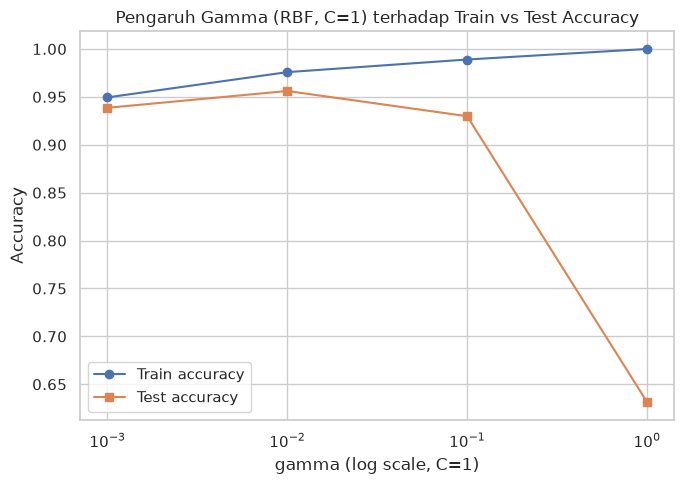

In [19]:
# Plot pengaruh gamma terhadap akurasi train vs test (sumbu x logaritmik).
train_acc_g = [models_g[g].score(X_train_s, y_train) for g in gamma_values]
test_acc_g = [accuracy_score(y_test, models_g[g].predict(X_test_s)) for g in gamma_values]
summary_g = pd.DataFrame({"gamma": gamma_values, "train_acc": np.round(train_acc_g, 4),
                          "test_acc": np.round(test_acc_g, 4),
                          "n_sv": [int(models_g[g].n_support_.sum()) for g in gamma_values]})
print(summary_g.to_string(index=False))

plt.figure(figsize=(7, 5))
plt.plot(gamma_values, train_acc_g, marker="o", label="Train accuracy")
plt.plot(gamma_values, test_acc_g, marker="s", label="Test accuracy")
plt.xscale("log")
plt.xlabel("gamma (log scale, C=1)")
plt.ylabel("Accuracy")
plt.title("Pengaruh Gamma (RBF, C=1) terhadap Train vs Test Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [20]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def scores(y_true, y_pred):
    return [accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred),
            recall_score(y_true, y_pred),
            f1_score(y_true, y_pred)]

comparison = pd.DataFrame(
    [scores(y_test, y_pred_linear), scores(y_test, y_pred_rbf)],
    index=["Linear (C=1)", "RBF (C=1, gamma=scale)"],
    columns=["Accuracy", "Precision", "Recall", "F1"])
print(comparison.round(4))
print()
print("Classification report — Linear:")
print(classification_report(y_test, y_pred_linear, target_names=["B (0)", "M (1)"]))
print("Classification report — RBF:")
print(classification_report(y_test, y_pred_rbf, target_names=["B (0)", "M (1)"]))

                        Accuracy  Precision  Recall     F1
Linear (C=1)              0.9649        1.0  0.9048  0.950
RBF (C=1, gamma=scale)    0.9737        1.0  0.9286  0.963

Classification report — Linear:
              precision    recall  f1-score   support

       B (0)       0.95      1.00      0.97        72
       M (1)       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

Classification report — RBF:
              precision    recall  f1-score   support

       B (0)       0.96      1.00      0.98        72
       M (1)       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



CM Linear:
 [[72  0]
 [ 4 38]]
CM RBF:
 [[72  0]
 [ 3 39]]


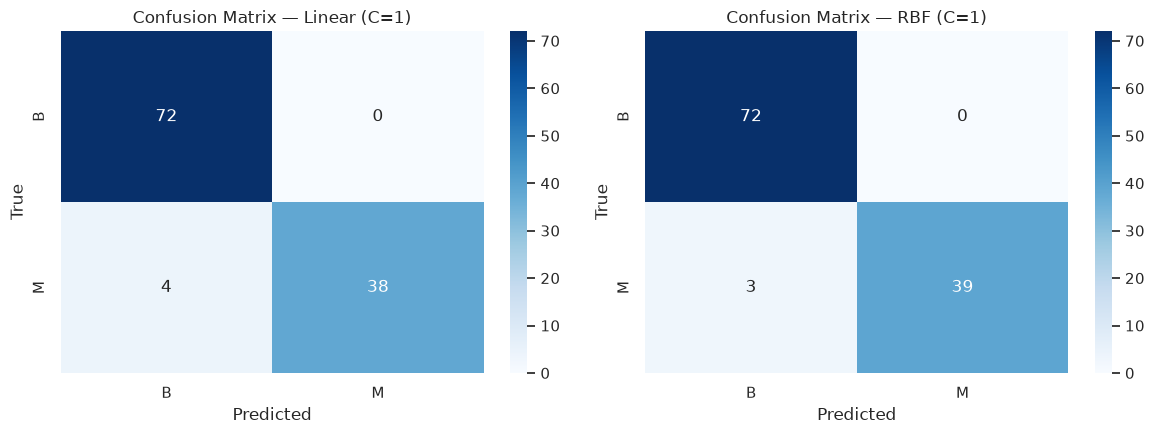

In [21]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
cm_linear = confusion_matrix(y_test, y_pred_linear)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
print("CM Linear:\n", cm_linear)
print("CM RBF:\n", cm_rbf)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, cm, title in zip(axes,
                          [cm_linear, cm_rbf],
                          ["Confusion Matrix — Linear (C=1)", "Confusion Matrix — RBF (C=1)"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["B", "M"], yticklabels=["B", "M"])
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

In [22]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.
sv_df = pd.DataFrame({"Linear": list(svm_linear.n_support_) + [int(svm_linear.n_support_.sum())],
                      "RBF": list(svm_rbf.n_support_) + [int(svm_rbf.n_support_.sum())]},
                     index=["n_SV kelas B (0)", "n_SV kelas M (1)", "Total n_SV"])
print(sv_df)
print(f"\nProporsi SV terhadap train ({len(y_train)} sampel): "
      f"linear={int(svm_linear.n_support_.sum())/len(y_train):.3f}, "
      f"RBF={int(svm_rbf.n_support_.sum())/len(y_train):.3f}")

                  Linear  RBF
n_SV kelas B (0)      19   50
n_SV kelas M (1)      19   57
Total n_SV            38  107

Proporsi SV terhadap train (455 sampel): linear=0.084, RBF=0.235


Explained variance ratio PCA-2D: [0.4459 0.1855] total: 0.6314
Akurasi test proksi PCA-2D: linear=0.9474, RBF=0.9298


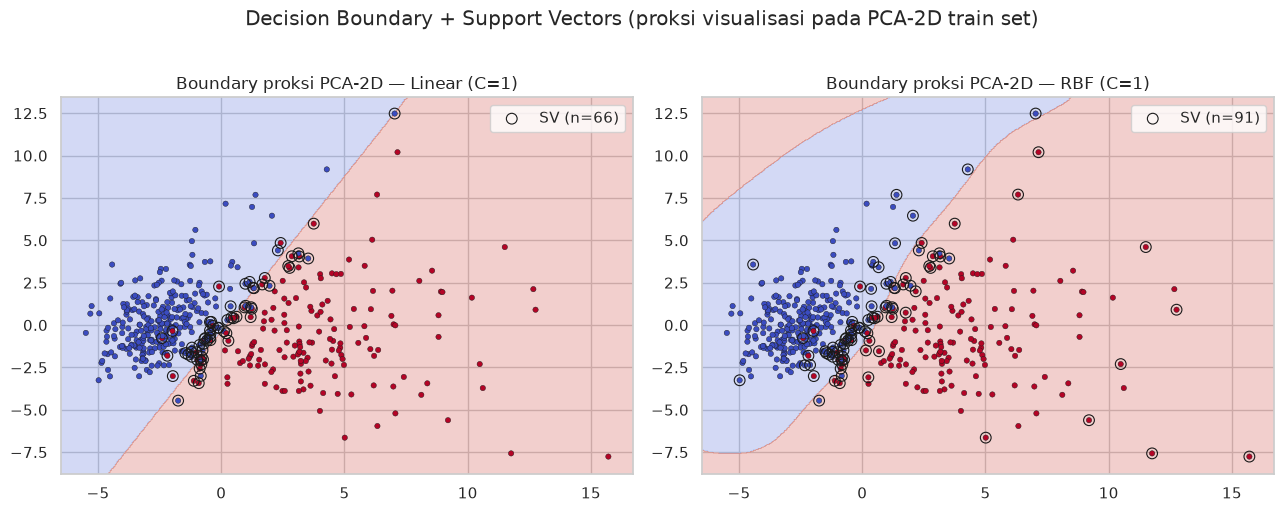

In [23]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.
# CATATAN: model utama dilatih pada 30 fitur sehingga boundary-nya tidak bisa diplot langsung.
# Sebagai PROKSI VISUALISASI, latih ulang SVC (linear & RBF, C=1) pada data yang direduksi PCA-2D (scaler di-fit ulang
# pada representasi yang sama), lalu plot boundary + support vectors di ruang PCA-2D ini.
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)
print("Explained variance ratio PCA-2D:", np.round(pca.explained_variance_ratio_, 4),
      "total:", round(float(pca.explained_variance_ratio_.sum()), 4))

svm_lin_2d = SVC(kernel="linear", C=1.0, random_state=42).fit(X_train_pca, y_train)
svm_rbf_2d = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42).fit(X_train_pca, y_train)
print(f"Akurasi test proksi PCA-2D: linear={svm_lin_2d.score(X_test_pca, y_test):.4f}, "
      f"RBF={svm_rbf_2d.score(X_test_pca, y_test):.4f}")

def plot_boundary(ax, model, Xp, y_true, title):
    h = 0.05
    x_min, x_max = Xp[:, 0].min() - 1, Xp[:, 0].max() + 1
    y_min, y_max = Xp[:, 1].min() - 1, Xp[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(Xp[:, 0], Xp[:, 1], c=np.asarray(y_true), cmap="coolwarm", s=15, edgecolors="k", linewidths=0.3)
    sv = model.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=60, facecolors="none", edgecolors="k", linewidths=0.8, label=f"SV (n={len(sv)})")
    ax.set_title(title)
    ax.legend(loc="best")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_boundary(axes[0], svm_lin_2d, X_train_pca, y_train, "Boundary proksi PCA-2D — Linear (C=1)")
plot_boundary(axes[1], svm_rbf_2d, X_train_pca, y_train, "Boundary proksi PCA-2D — RBF (C=1)")
plt.suptitle("Decision Boundary + Support Vectors (proksi visualisasi pada PCA-2D train set)", y=1.02)
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa SVM dengan kernel Linear vs RBF. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian, dikaitkan dengan bentuk sebaran data pada EDA?
- Jelaskan temuan dari eksperimen regularisasi (nilai `C`). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Bandingkan jumlah support vectors antara model Linear dan RBF. Apa hubungan jumlah support vectors dengan kompleksitas batas keputusan yang terbentuk?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

**Hasil eksperimen (test set 114 sampel, stratify, random_state=42; C=1, gamma='scale'):**

1. **Linear vs RBF:** akurasi test Linear **0.9649** vs RBF **0.9737** (selisih hanya 0.0088 / 1 sampel). Precision keduanya **1.0000** (tidak ada false positive: tidak ada kasus benign yang diprediksi malignant). Recall Linear **0.9048** vs RBF **0.9286**; F1 Linear **0.9500** vs RBF **0.9630**. Dari confusion matrix: Linear salah 4 sampel (semua false negative: 4 malignant terprediksi benign), RBF salah 3 sampel (3 false negative). Perbedaan kecil ini wajar: dari EDA, fitur-fitur top (`concave points_worst` r=0.79, `perimeter_worst` r=0.78, `radius_worst` r=0.78) distribusi histogram/boxplot antar kelas cukup terpisah sehingga hyperplane linear sudah hampir cukup; kernel RBF hanya menambah sedikit fleksibilitas untuk 1 sampel batas tambahan.
2. **Pengaruh C (RBF, gamma='scale', C=[0.01, 0.1, 1, 10, 100]):** train/test = 0.6264/0.6316 (C=0.01) -> 0.9538/0.9474 (C=0.1) -> 0.9868/0.9737 (C=1) -> 0.9890/0.9737 (C=10) -> 1.0000/0.9649 (C=100). C=0.01 jelas **underfitting** (margin terlalu lebar, akurasi ~63% mendekati proporsi kelas mayoritas 62.7%). Kenaikan C mempersempit margin dan menambah akurasi train; gejala **overfitting mulai terlihat pada C=100**: train mencapai 1.0000 tetapi test turun dari 0.9737 ke 0.9649 (gap train-test melebar dari 0.0153 menjadi 0.0351). C=1/10 adalah titik seimbang (test tertinggi 0.9737). Jumlah support vectors turun seiring C naik: 341 -> 202 -> 107 -> 82 -> 70, konsisten dengan margin yang menyempit.
3. **Pengaruh gamma (RBF, C=1, gamma=[0.001, 0.01, 0.1, 1]):** train/test = 0.9495/0.9386 (0.001) -> 0.9758/0.9561 (0.01) -> 0.9890/0.9298 (0.1) -> 1.0000/0.6316 (1). Gamma=1 menunjukkan **overfitting ekstrem**: train 1.0000 tetapi test anjlok ke 0.6316 (setara tebakan mayoritas) dengan n_SV membengkak ke 455 (hampir seluruh train menjadi support vector, tiap titik hanya memengaruhi sekitarnya). Gamma kecil (0.001) memberi boundary halus dengan n_SV=176; gamma terbaik di grid ini adalah 0.01 (test 0.9561) atau default `scale` (~0.033, test 0.9737).
4. **Support vectors:** model 30-fitur Linear total **38 SV** (19 B + 19 M, ~8.4% data train) vs RBF total **107 SV** (50 B + 57 M, ~23.5% data train). SV Linear jauh lebih sedikit karena boundary-nya satu hyperplane global yang hanya ditopang titik-titik dekat margin; RBF membentuk boundary non-linear yang ditopang lebih banyak titik. Ini sejalan dengan teori: boundary lebih kompleks = lebih banyak support vectors. Kelas M menyumbang SV sedikit lebih banyak pada RBF (57 vs 50), menandakan sampel malignant lebih tersebar/dekat batas.


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba kernel Polynomial, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Kesimpulan:**

1. Pada dataset Breast Cancer Wisconsin (569 sampel, 30 fitur, target M=212/B=357), SVM Linear (C=1) dan RBF (C=1, gamma='scale') keduanya sangat baik: akurasi test **0.9649** (Linear) vs **0.9737** (RBF), precision **1.0000** keduanya, recall **0.9048** vs **0.9286**, F1 **0.9500** vs **0.9630**. RBF unggul tipis (+0.0088 akurasi, +1 sampel benar) sehingga dipilih sebagai model terbaik, tetapi data pada dasarnya sudah cukup linearly separable.
2. Parameter C mengontrol trade-off margin vs kesalahan: C=0.01 underfitting (0.6316), C=1/10 optimal (test 0.9737), C=100 overfitting (train 1.0000, test turun ke 0.9649). Parameter gamma mengontrol kelokalan RBF: gamma=1 overfitting ekstrem (test 0.6316, n_SV=455), gamma kecil lebih general.
3. Jumlah support vectors mencerminkan kompleksitas: Linear **38** vs RBF **107**; C/gamma besar yang mempersempit/melokalkan boundary mengubah n_SV secara sistematis (C naik -> n_SV turun 341->70; gamma naik -> n_SV naik 176->455 pada ujung ekstrem).
4. Keterbatasan: tuning hanya grid kecil tanpa cross-validation, sehingga pemilihan C/gamma memakai skor test-set (sedikit optimistis); scaling sudah benar (fit hanya di train).